# QSVT Linear-System Comparisons

This notebook compares the finite dense linear-system reference solve, conjugate gradients, and the QSVT-style polynomial inverse workflow on the same positive-definite instance.

Goals:

- inspect solver rows in a compact human-readable table
- track how polynomial degree affects residual and solution error
- keep the QSVT resource-proxy fields separate from timing or hardware claims


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src" / "qsvt").exists():
    ROOT = Path.cwd().parents[0]
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from qsvt.algorithms import (
    linear_system_comparison_summary_table,
    linear_system_comparison_workflow,
)

np.set_printoptions(precision=4, suppress=True)


def print_rows(rows, columns):
    widths = {
        column: max(
            len(column),
            *(len(format_value(row.get(column))) for row in rows),
        )
        for column in columns
    }
    header = "  ".join(column.ljust(widths[column]) for column in columns)
    rule = "  ".join("-" * widths[column] for column in columns)
    print(header)
    print(rule)
    for row in rows:
        print(
            "  ".join(
                format_value(row.get(column)).ljust(widths[column])
                for column in columns
            )
        )


def format_value(value):
    if value is None:
        return "-"
    if isinstance(value, float):
        return f"{value:.3e}" if abs(value) < 1e-3 else f"{value:.6g}"
    return str(value)


## A Small Positive-Definite System

The matrix is intentionally small so every row can be checked against an exact dense solve. The QSVT-style row measures polynomial inverse accuracy, not quantum runtime.

In [2]:
A = np.array(
    [
        [2.0, 0.25],
        [0.25, 1.25],
    ],
)
b = np.array([1.0, -0.5])

comparison = linear_system_comparison_workflow(
    A,
    b,
    degree=8,
    num_points=201,
    bounded_num_points=401,
    attempt_synthesis=False,
    apply_qsvt=False,
    cg_tolerance=1e-12,
)

rows = linear_system_comparison_summary_table(comparison)
print_rows(
    rows,
    [
        "solver",
        "implementation_kind",
        "degree",
        "iterations",
        "residual_norm",
        "relative_solution_error",
    ],
)


solver                         implementation_kind                 degree  iterations  residual_norm  relative_solution_error
-----------------------------  ----------------------------------  ------  ----------  -------------  -----------------------
dense_solve                    classical-dense-reference           8       -           5.551e-17      0.000e+00              
conjugate_gradient             classical-iterative-reference       8       2           5.551e-17      0.000e+00              
qsvt_style_polynomial_inverse  dense-spectral-polynomial-workflow  8       -           0.0575533      0.0571796              


## Conditioning And Degree

The linear-system report exposes both the true dense condition number and the `1 / gamma` proxy used by the positive-inverse polynomial design.

In [3]:
resource_proxy = comparison.as_report()["resource_proxy"]
proxy_rows = [
    {"quantity": "degree", "value": resource_proxy["degree"]},
    {"quantity": "gamma", "value": resource_proxy["gamma"]},
    {
        "quantity": "condition_number_2",
        "value": resource_proxy["condition_number_2"],
    },
    {
        "quantity": "gamma_condition_proxy",
        "value": resource_proxy["gamma_condition_proxy"],
    },
    {
        "quantity": "polynomial_relative_error",
        "value": resource_proxy["polynomial_relative_error"],
    },
]
print_rows(proxy_rows, ["quantity", "value"])


quantity                   value    
-------------------------  ---------
degree                     8        
gamma                      0.565741 
condition_number_2         1.76759  
gamma_condition_proxy      1.76759  
polynomial_relative_error  0.0571796


In [4]:
degree_rows = []
for degree in [4, 6, 8, 10]:
    sweep = linear_system_comparison_workflow(
        A,
        b,
        degree=degree,
        num_points=201,
        bounded_num_points=401,
        attempt_synthesis=False,
        apply_qsvt=False,
        include_conjugate_gradient=False,
    )
    qsvt_style = [
        row
        for row in linear_system_comparison_summary_table(sweep)
        if row["solver"] == "qsvt_style_polynomial_inverse"
    ][0]
    degree_rows.append(
        {
            "degree": degree,
            "relative_solution_error": qsvt_style["relative_solution_error"],
            "residual_norm": qsvt_style["residual_norm"],
        }
    )

print_rows(degree_rows, ["degree", "relative_solution_error", "residual_norm"])


degree  relative_solution_error  residual_norm
------  -----------------------  -------------
4       0.104276                 0.134979     
6       0.0578489                0.0549513    
8       0.0571796                0.0575533    
10      0.0438395                0.0489511    


## Degree Sweep Plot

The plot shows the same degree sweep as the table. Higher degree improves this finite instance until numerical and design choices dominate.

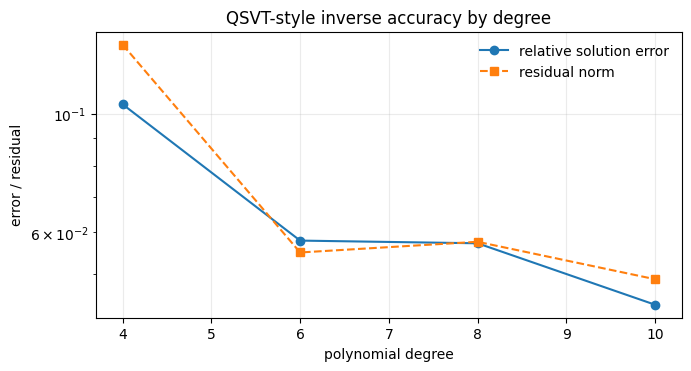

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)

degrees = [row["degree"] for row in degree_rows]
errors = [row["relative_solution_error"] for row in degree_rows]
residuals = [row["residual_norm"] for row in degree_rows]

ax.semilogy(degrees, errors, "o-", label="relative solution error")
ax.semilogy(degrees, residuals, "s--", label="residual norm")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("error / residual")
ax.set_title("QSVT-style inverse accuracy by degree")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
plt.show()


## Artifact Shape

`comparison.as_report()` is the full JSON payload. `linear_system_comparison_summary_table(...)` is the compact CSV-friendly table used by the CLI `linear-system-compare --rows-output` path.